# Clasificación MNIST con SVM

In [1]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
# Cargar los datos
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalizar los píxeles (rango 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

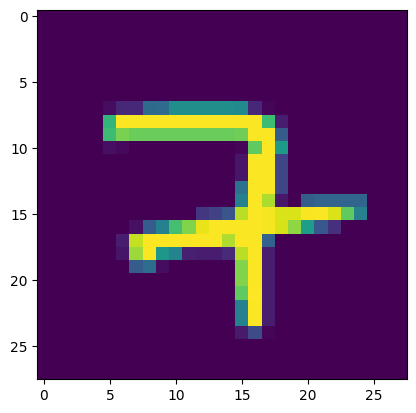

In [3]:
plt.imshow(x_train[38], interpolation='nearest')
plt.show()

"Desenrrollamos" la matriz en un vector

In [4]:
x_train_vector = x_train.reshape(60000, 28*28)

Inicializamos el modelo de máquina de vector de soporte

In [5]:
svm = SVC(C = 1, kernel='rbf', gamma = 'scale')
svm.fit(x_train_vector, y_train)

SVC(C=1)

Procedemos a obtener la métrica de accuracy

In [6]:
x_test_vector = x_test.reshape(10000, 28*28)

In [7]:
y_pred = svm.predict(x_test_vector)
print(accuracy_score(y_pred, y_test))

0.9792


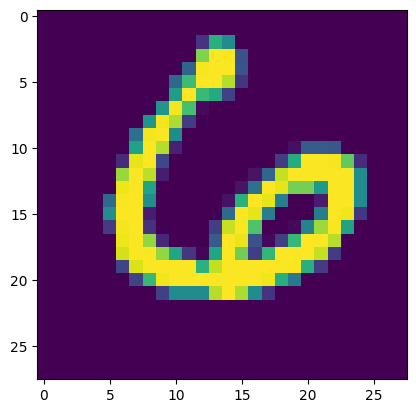

In [26]:
plt.imshow(x_test[201], interpolation='nearest')
plt.show()

Realicemos una reducción de dimensionalidad

In [28]:
pca_153 = PCA(n_components = 153).fit(x_train_vector)

In [29]:
x_train_vector_reduced = pca_153.transform(x_train_vector)

Probaremos ahora un modelo para los datos reducidos

In [33]:
svm_reduced = SVC(C = 1, kernel='poly', gamma = 'scale', degree = 5)
svm_reduced.fit(x_train_vector_reduced, y_train)

SVC(C=1, degree=5, kernel='poly')

Obtenemos ahora el desemempeño de este nuevo modelo

In [34]:
x_test_vector_reduced = pca_153.transform(x_test_vector)

In [35]:
y_pred_reduced = svm_reduced.predict(x_test_vector_reduced)
print(accuracy_score(y_pred_reduced, y_test))

0.973
